In [45]:
import os
import re
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import torch 
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader,random_split,Subset
import torchvision
import torchvision.transforms as T
from transformers import VisionEncoderDecoderModel
from transformers import ViTModel, ViTImageProcessor
from transformers import GPT2Tokenizer, GPT2LMHeadModel, GPT2Config
from sacrebleu import corpus_bleu
from tqdm import tqdm
import requests
from io import BytesIO

In [3]:
df = pd.read_csv(r'/kaggle/input/flickr-image-dataset/flickr30k_images/results.csv',delimiter='|')
df.shape

(158915, 3)

In [4]:
df.head(5)

,image_name,comment_number,comment
0,1000092795.jpg,0,Two young guys with shaggy hair look at their...
1,1000092795.jpg,1,"Two young , White males are outside near many..."
2,1000092795.jpg,2,Two men in green shirts are standing in a yard .
3,1000092795.jpg,3,A man in a blue shirt standing in a garden .
4,1000092795.jpg,4,Two friends enjoy time spent together .


In [5]:
df.columns

Index(['image_name', ' comment_number', ' comment'], dtype='object')

In [6]:
df.drop(' comment_number',axis=1,inplace=True)

In [7]:
df = df.rename(columns={' comment': 'comment'})

In [8]:
df['image_name'].value_counts()

image_name
998845445.jpg     5
1000092795.jpg    5
10002456.jpg      5
1000268201.jpg    5
1000344755.jpg    5
                 ..
1001573224.jpg    5
1001633352.jpg    5
1001773457.jpg    5
1001896054.jpg    5
100197432.jpg     5
Name: count, Length: 31783, dtype: int64

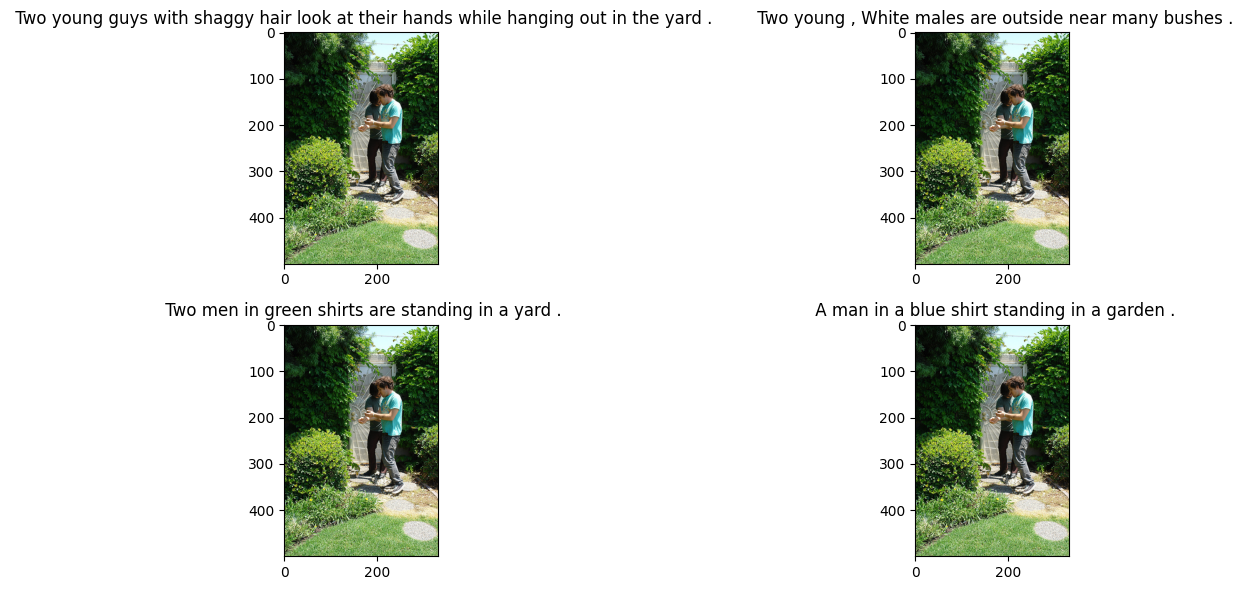

In [9]:
fig,ax = plt.subplots(nrows=2,ncols=2,figsize=(17,6))
for i,ax in enumerate(ax.flatten()):
    img = os.path.join(f"/kaggle/input/flickr-image-dataset/flickr30k_images/flickr30k_images/{df.iloc[i]['image_name']}")
    img = cv2.imread(img)
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(df.iloc[i]['comment'])
plt.tight_layout()

In [10]:
df = df[~df['comment'].isnull()]

In [11]:
def remove_special(txt):
    txt = txt.lower()
    return re.sub(r'[^a-z0-9,?\'\-\s]', '', txt)

df['comment'] = df['comment'].apply(remove_special)

In [12]:
df.sample(5)

,image_name,comment
122919,4873065486.jpg,two children are eating something outside
47864,2899374885.jpg,a baby reaching into a water fountain
8835,1489471156.jpg,a group of nicely dressed young women in new ...
72274,34728392.jpg,a woman sitting on a bench reading a book
47235,2886837407.jpg,two asian children smile while hugging each o...


In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [14]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
config = GPT2Config.from_pretrained("gpt2")
config.add_cross_attention = True  
gpt = GPT2LMHeadModel.from_pretrained("gpt2", config=config).to(device)

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Some weights of GPT2LMHeadModel were not initialized from the model checkpoint at gpt2 and are newly initialized: ['transformer.h.0.crossattention.c_attn.bias', 'transformer.h.0.crossattention.c_attn.weight', 'transformer.h.0.crossattention.c_proj.bias', 'transformer.h.0.crossattention.c_proj.weight', 'transformer.h.0.crossattention.q_attn.bias', 'transformer.h.0.crossattention.q_attn.weight', 'transformer.h.0.ln_cross_attn.bias', 'transformer.h.0.ln_cross_attn.weight', 'transformer.h.1.crossattention.c_attn.bias', 'transformer.h.1.crossattention.c_attn.weight', 'transformer.h.1.crossattention.c_proj.bias', 'transformer.h.1.crossattention.c_proj.weight', 'transformer.h.1.crossattention.q_attn.bias', 'transformer.h.1.crossattention.q_attn.weight', 'transformer.h.1.ln_cross_attn.bias', 'transformer.h.1.ln_cross_attn.weight', 'transformer.h.10.crossattention.c_attn.bias', 'transformer.h.10.crossattention.c_attn.weight', 'transformer.h.10.crossattention.c_proj.bias', 'transformer.h.10.cros

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [15]:
gpt

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (crossattention): GPT2Attention(
          (c_attn): Conv1D(nf=1536, nx=768)
          (q_attn): Conv1D(nf=768, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_cross_attn): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): C

In [16]:
tokenizer.special_tokens_map

{'bos_token': '<|endoftext|>',
 'eos_token': '<|endoftext|>',
 'unk_token': '<|endoftext|>'}

In [17]:
tokenizer.add_special_tokens({'pad_token': '<|pad|>'})
gpt.resize_token_embeddings(len(tokenizer),mean_resizing=False)
gpt.config.pad_token_id = tokenizer.pad_token_id

In [18]:
print('sos token:',tokenizer.bos_token_id)
print('eos token:',tokenizer.eos_token_id)
print('pad token:',tokenizer.pad_token_id)

sos token: 50256
eos token: 50256
pad token: 50257


In [19]:
processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
vit = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k").to(device)
for p in vit.parameters():
    p.requires_grad = False

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [20]:
vit

ViTModel(
  (embeddings): ViTEmbeddings(
    (patch_embeddings): ViTPatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): ViTEncoder(
    (layer): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (attention): ViTSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): ViTSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (intermediate): ViTIntermediate(
          (dense): Linear(in_features=768, out_features=3072, bias=True)
          (intermediate_act_fn): GELUActivation()
        )
        (output): ViTOutput(
          (d

In [21]:
class ImageCaptionDataset(Dataset):
    def __init__(self, df, tokenizer, feature_extractor, max_length=100):
        self.df = df
        self.tokenizer = tokenizer
        self.feature_extractor = feature_extractor
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # 1) load and preprocess image
        img_name = self.df.iloc[idx]['image_name']
        img_path = os.path.join(
            "/kaggle/input/flickr-image-dataset/flickr30k_images/flickr30k_images/",
            img_name
        )
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        img = Image.fromarray(img)

        fe_outputs = self.feature_extractor(
            images=img,
            return_tensors="pt"
        )
        
        pixel_values = fe_outputs.pixel_values.squeeze(0)

        caption = self.df.iloc[idx]['comment']
        caption = f"{tokenizer.bos_token} {caption} {tokenizer.eos_token}"
        tok_outputs = self.tokenizer(
            caption,
            max_length = self.max_length,
            padding= 'max_length',
            truncation=True,
            return_tensors="pt"
        )
        input_ids = tok_outputs.input_ids.squeeze(0)
        attention_mask = tok_outputs.attention_mask.squeeze(0)

        return {
            "img": pixel_values,
            "input_id":     input_ids,
            "attention_mask": attention_mask
        }

In [22]:
dataset = ImageCaptionDataset(df, tokenizer, feature_extractor=processor)

In [23]:
dataset[0]

{'img': tensor([[[-0.9765, -0.9686, -0.9608,  ...,  0.5059,  0.7176,  0.7176],
          [-0.9765, -0.9608, -0.9686,  ...,  0.4275,  0.1922,  0.4667],
          [-0.9529, -0.9686, -0.9608,  ..., -0.4588, -0.4588, -0.1765],
          ...,
          [-0.3882, -0.2392, -0.2627,  ...,  0.0667,  0.1059,  0.0510],
          [-0.1373,  0.1137,  0.0745,  ...,  0.1451,  0.0667,  0.1294],
          [ 0.3412,  0.2157,  0.0039,  ...,  0.1922,  0.2157,  0.1137]],
 
         [[-0.9529, -0.9529, -0.9529,  ...,  0.7725,  0.9294,  0.9608],
          [-0.9686, -0.9529, -0.9529,  ...,  0.7255,  0.5451,  0.8039],
          [-0.9216, -0.9529, -0.9529,  ..., -0.0431, -0.0196,  0.3020],
          ...,
          [-0.1922, -0.1608, -0.1843,  ...,  0.4118,  0.3961,  0.3569],
          [ 0.0431,  0.2941,  0.3176,  ...,  0.4275,  0.3333,  0.4196],
          [ 0.4824,  0.4510,  0.4039,  ...,  0.3961,  0.4510,  0.3490]],
 
         [[-0.9608, -0.9608, -0.9608,  ...,  0.8196,  0.9451,  0.9843],
          [-0.9765, -

In [24]:
tokenizer.decode([50256,   220,   734,  1862,  3730,   351,   427,   363,  1360,  4190,
           804,   379,   511,  2832,   981, 10938,   503,   287,   262, 12699,
           220,   220, 50256, 50257, 50257, 50257, 50257, 50257, 50257, 50257,
         50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257,
         50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257,
         50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257,
         50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257,
         50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257,
         50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257,
         50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257])

'<|endoftext|>  two young guys with shaggy hair look at their hands while hanging out in the yard  <|endoftext|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|>'

In [25]:
model = VisionEncoderDecoderModel(encoder=vit,decoder=gpt).to(device)

In [26]:
model.config.decoder_start_token_id = tokenizer.bos_token_id
model.config.pad_token_id = tokenizer.pad_token_id
model.config.decoder_end_token_id = tokenizer.eos_token_id
model.config.loss_type = "ForCausalLMLoss"

In [27]:
model

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (inte

In [28]:
class ImageCaptioningModel(nn.Module):
    def __init__(self, model, tokenizer):
        super(ImageCaptioningModel, self).__init__()
        self.model = model
        self.tokenizer = tokenizer
        
    def forward(self, pixel_values, input_ids, attention_mask,labels=None):
        outputs = self.model(
            pixel_values=pixel_values,
            decoder_input_ids=input_ids,  
            decoder_attention_mask=attention_mask, 
            labels=input_ids,  
        )
        return outputs
    
    def generate_caption(self, pixel_values, max_length=100):
        with torch.no_grad():
            generated_ids = self.model.generate(
                pixel_values=pixel_values,
                max_length=max_length,
                num_beams = 3,
                attention_mask = None
            )
        return self.tokenizer.batch_decode(generated_ids, skip_special_tokens=True)

In [29]:
vision_model = ImageCaptioningModel(
    model=model,
    tokenizer=tokenizer,
).to(device)

optimizer = torch.optim.AdamW(vision_model.parameters(), lr=1e-4, weight_decay=0.0005)

In [30]:
train_size = int(0.95 * len(dataset))
val_size = len(dataset) - train_size
trainset, valset = random_split(dataset, [train_size, val_size])
print(f"Training data: {len(trainset)} samples")
print(f"Validation data: {len(valset)} samples")

Training data: 150968 samples
Validation data: 7946 samples


In [31]:
batch_size = 32
train_loader = DataLoader(trainset,batch_size=batch_size,shuffle=True,num_workers=2)
val_loader = DataLoader(valset,batch_size=batch_size,shuffle=False,num_workers=2)

In [32]:
def train_epoch(model, dataloader, optimizer, device):
    model.train()
    epoch_loss = 0

    for batch in tqdm(dataloader):  
        pixel_values = batch["img"].to(device)
        input_ids = batch["input_id"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=input_ids
        )

        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += loss.item()

    print('Train Loss:', epoch_loss / len(dataloader))

In [36]:
def validate(model, dataloader, device, tokenizer):
    model.eval()
    epoch_loss = 0
    all_predictions = []
    all_references = []

    with torch.no_grad():
        for batch in dataloader:
            pixel_values = batch["img"].to(device)
            input_ids = batch["input_id"].to(device)
            attention_mask = batch["attention_mask"].to(device)
     
            outputs = model(
                pixel_values=pixel_values,
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=input_ids
            )
            loss = outputs.loss
            
            generated_caps = model.generate_caption(pixel_values=pixel_values)
            
            references = tokenizer.batch_decode(input_ids, skip_special_tokens=True)
            all_predictions.extend(generated_caps)
            all_references.extend([[ref] for ref in references])

    bleu_score = corpus_bleu(all_predictions,all_references, lowercase=True)

    print('Validation Loss:', epoch_loss / len(dataloader))
    print('BLEU Score:', bleu_score.score)

    return epoch_loss / len(dataloader),bleu_score.score

In [37]:
def train_model(model, train_loader, val_loader, optimizer, num_epochs, device):
    best_val_loss = float('inf')
    best_bleu = 0
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        
        train_epoch(model, train_loader, optimizer, device)
        
        val_loss,bleu = validate(model, val_loader, device, tokenizer)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "captioning_model.pt")
            print("Model saved!")
            
        elif bleu>best_bleu:
            best_bleu = bleu
            torch.save(model.state_dict(), "captioning_model.pt")
            print("Model saved!")
            
    return model

In [38]:
num_epochs = 1

trained_model = train_model(
    model=vision_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    num_epochs=num_epochs,
    device=device
)


Epoch 1/1


100%|██████████| 4718/4718 [1:06:54<00:00,  1.18it/s]

Train Loss: 0.3362920294883343



We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.


Validation Loss: 0.0
BLEU Score: 90.36020036098445
Model saved!


In [46]:
def test_model(model, url, tokenizer, processor, device):
    model.eval()

    response = requests.get(url)
    image = Image.open(BytesIO(response.content)).convert("RGB")
    
    inputs = processor(images=image, return_tensors="pt")
    pixel_values = inputs['pixel_values'].to(device) 
    
    with torch.no_grad():
        caption = model.generate_caption(pixel_values)[0] 
    
    # Display results
    plt.imshow(image)
    plt.title(caption)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

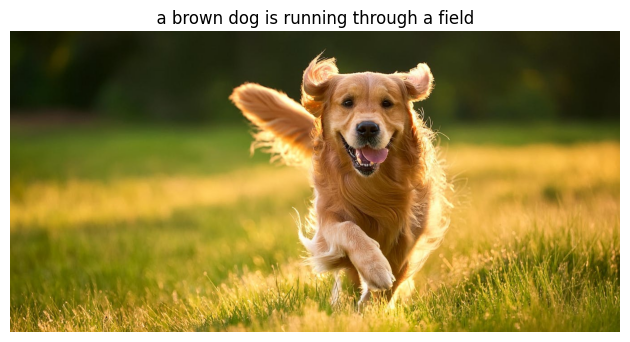

In [47]:
url = 'https://images.theconversation.com/files/625049/original/file-20241010-15-95v3ha.jpg?ixlib=rb-4.1.0&rect=12%2C96%2C2671%2C1335&q=45&auto=format&w=1356&h=668&fit=crop'
test_model(trained_model,url,tokenizer,processor,device)

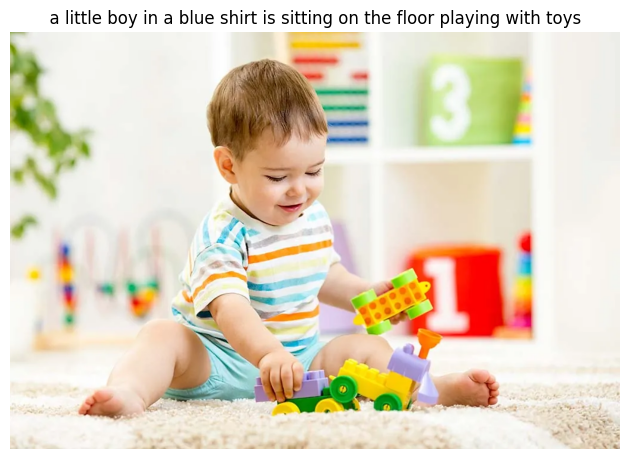

In [48]:
url = 'https://cdn.cdnparenting.com/articles/2022/04/07114528/227386435.webp'
test_model(trained_model,url,tokenizer,processor,device)

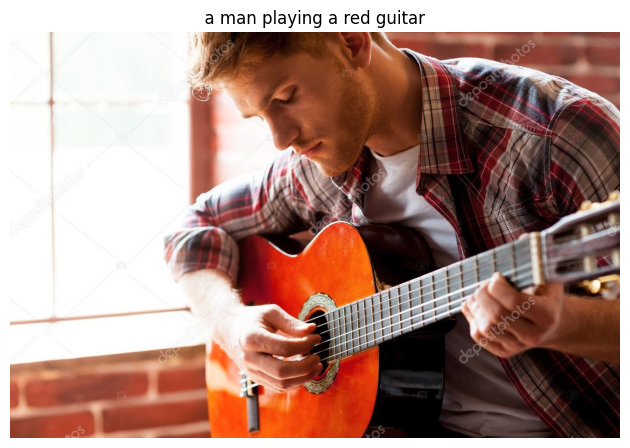

In [49]:
url = 'https://st.depositphotos.com/2931363/4690/i/950/depositphotos_46903011-stock-photo-handsome-man-playing-guitar.jpg'
test_model(trained_model,url,tokenizer,processor,device)

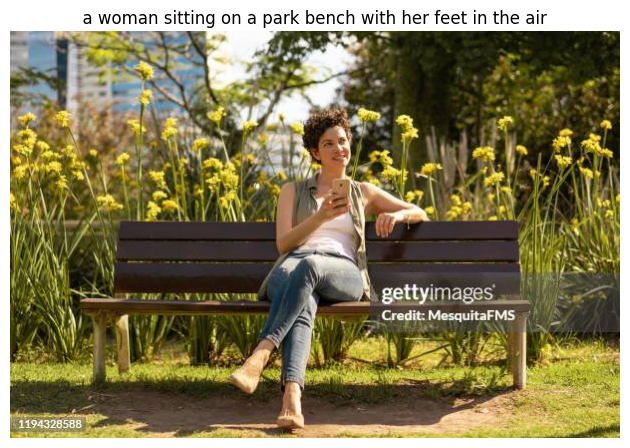

In [50]:
url = 'https://media.gettyimages.com/id/1194328588/photo/beautiful-woman-sitting-on-public-square-bench-talking-on-cellphone.jpg?s=612x612&w=gi&k=20&c=0uCIEQD3Dk5RBn1uZQzhKjOgl5EcYjPwYfjJQXzCfc4='
test_model(trained_model,url,tokenizer,processor,device)

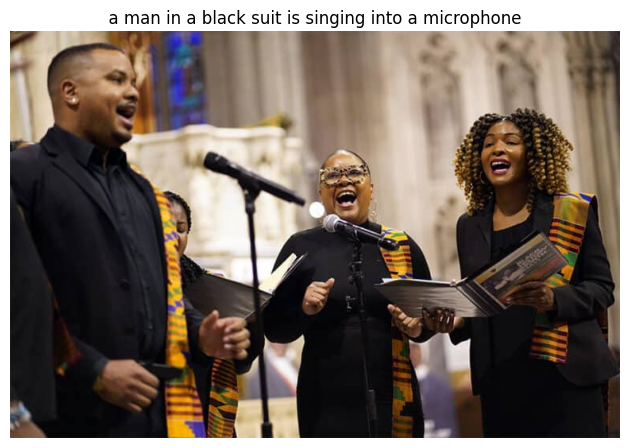

In [51]:
url = 'https://catholicreview.org/wp-content/uploads/2024/03/mass-singing-768x512.jpg'
test_model(trained_model,url,tokenizer,processor,device)

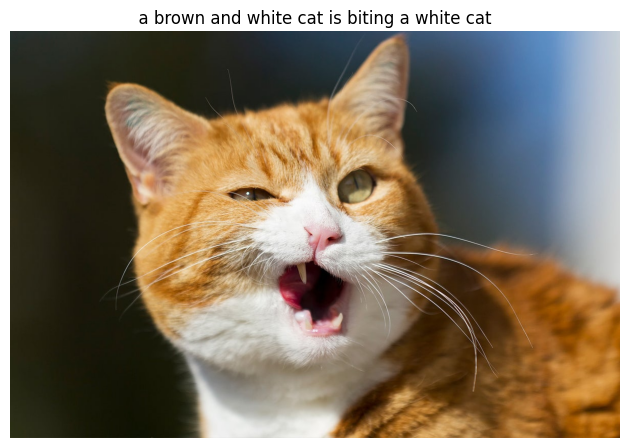

In [58]:
url = 'https://static.scientificamerican.com/sciam/cache/file/2AE14CDD-1265-470C-9B15F49024186C10_source.jpg?w=1200'
test_model(trained_model,url,tokenizer,processor,device)

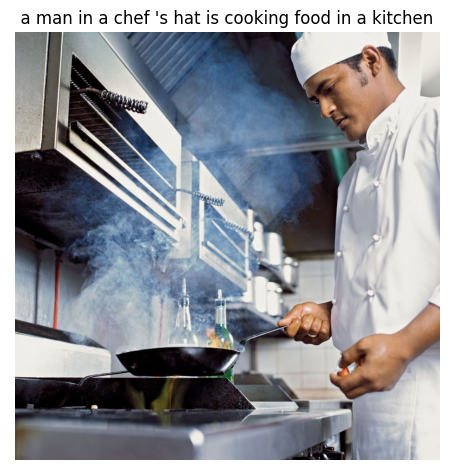

In [53]:
url = 'https://cdn.britannica.com/86/145786-050-5BD27317/chef-cooking-restaurant-kitchen.jpg'
test_model(trained_model,url,tokenizer,processor,device)

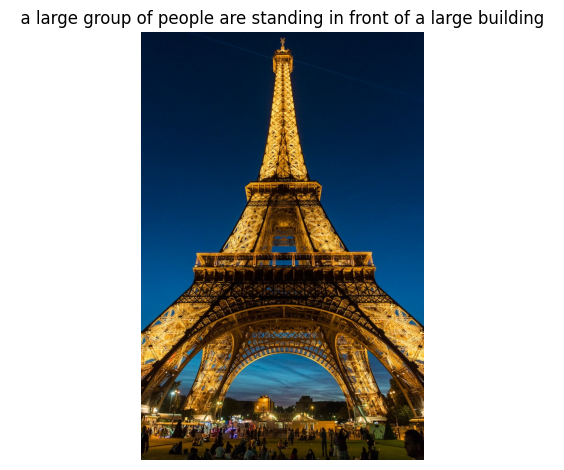

In [73]:
url = 'https://i.etsystatic.com/8026687/r/il/e16641/1436085510/il_570xN.1436085510_8o7t.jpg'
test_model(trained_model,url,tokenizer,processor,device)

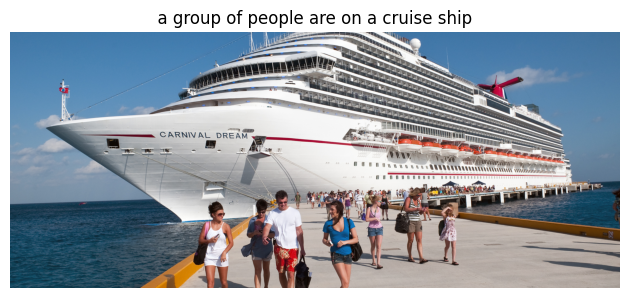

In [76]:
url = 'https://cdn.cheapism.com/images/042318_people_should_not_go_on_a_.2e16d0ba.fill-1440x605_xkUdGFH.png'
test_model(trained_model,url,tokenizer,processor,device)